Dataset Preview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

SIMPLE LINEAR REGRESSION
MSE: 0.7108
RMSE: 0.8431
R2 Score: 0.4576


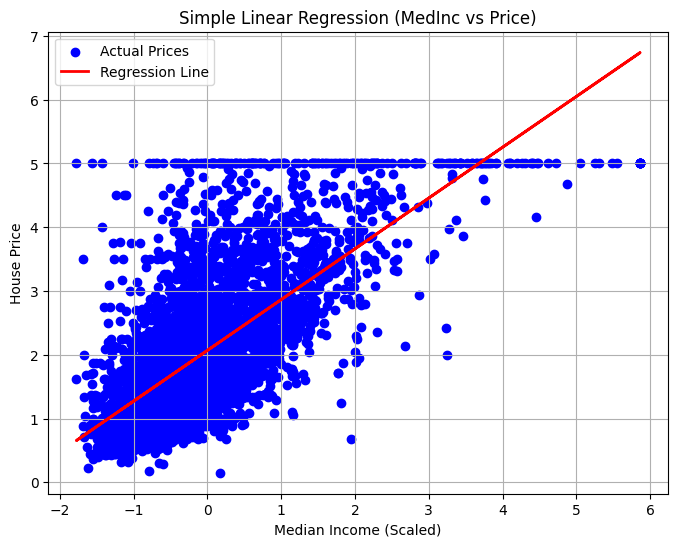


MULTIPLE LINEAR REGRESSION
MSE: 0.5573
RMSE: 0.7465
R2 Score: 0.5747


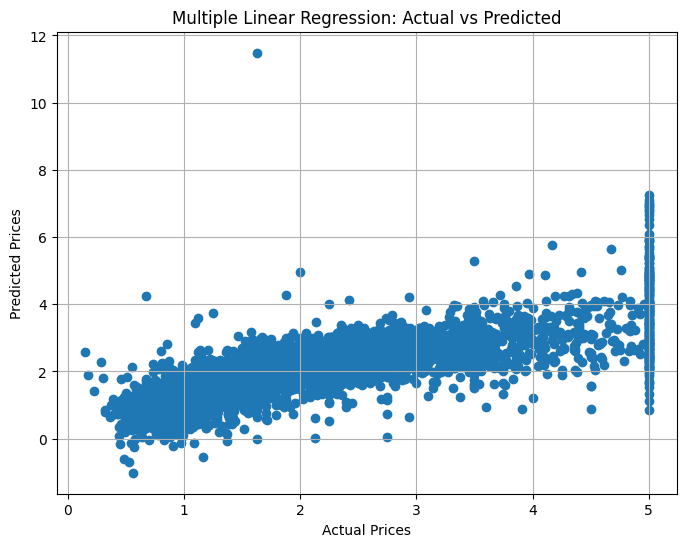


MODEL COMPARISON
Simple Linear Regression R2: 0.4576
Multiple Linear Regression R2: 0.5747


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Dataset Preview:")
print(df.head())

df.iloc[0:10, 0] = np.nan

imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

scaler = StandardScaler()

X = df_imputed.drop("Price", axis=1)
y = df_imputed["Price"]

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nSIMPLE LINEAR REGRESSION")

# Using only one feature (e.g., 'MedInc')
X_simple = X_scaled[:, housing.feature_names.index("MedInc")].reshape(-1, 1)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

# Evaluation
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print(f"MSE: {mse_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")
print(f"R2 Score: {r2_simple:.4f}")

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_test_s, y_test_s, color='blue', label="Actual Prices")
plt.plot(X_test_s, y_pred_simple, color='red', linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression (MedInc vs Price)")
plt.xlabel("Median Income (Scaled)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()

print("\nMULTIPLE LINEAR REGRESSION")

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

# Evaluation
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f"MSE: {mse_multiple:.4f}")
print(f"RMSE: {rmse_multiple:.4f}")
print(f"R2 Score: {r2_multiple:.4f}")

# Visualization: Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_multiple)
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()

print("\nMODEL COMPARISON")
print("Simple Linear Regression R2:", round(r2_simple,4))
print("Multiple Linear Regression R2:", round(r2_multiple,4))
